In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")


In [ ]:
data_raw_path = (
    r"C:\Users\kottu\Desktop\UNICUS\PYTHON\DATA\Kaggle\articles data\data.raw.json"
)
extra_large_path = (
    r"C:\Users\kottu\Desktop\UNICUS\PYTHON\DATA\Kaggle\articles data\extra_large.json"
)
topics_csv_path = (
    r"C:\Users\kottu\Desktop\UNICUS\PYTHON\DATA\Kaggle\articles data\topics.csv"
)

with open(data_raw_path, "r") as file:
    data_raw = json.load(file)

df_articles = pd.DataFrame(data_raw)
print(f"Loaded articles data with shape: {df_articles.shape}")

with open(extra_large_path, "r") as file:
    extra_large = json.load(file)
print("Loaded extra_large JSON data")

df_topics = pd.read_csv(topics_csv_path, encoding="ascii")
print(f"Loaded topics CSV data with shape: {df_topics.shape}")

df_articles.head()


Loaded articles data with shape: (22134, 8)
Loaded extra_large JSON data
Loaded topics CSV data with shape: (18, 3)


,id,title,abstract,keywords,authors,venue,date,teams
0,5096000,Diffusion-based spectral super-resolution of t...,Third octave spectral recording of acoustic se...,"[speech privacy, generative audio, acoustic se...","[Modan Tailleur, Chaymae Benaatia, Mathieu Lag...",[info.info-ai],2025-09-08T00:00:00Z,"[AAU, LS2N]"
1,5113219,Ambiances. A Sensitivity to Ordinary Situations,"How do ambiances shape our sensory, social, an...","[ambiance, atmosphere, ambiances, atmospheres,...","[Jean-Paul Thibaud, Nicolas Tixier, David Zerbib]","[shs.archi, sde.es, shs, shs.art]",2025-09-08T00:00:00Z,[AAU]
2,5129109,Sensory Urban Mobilities: Experiences and Uses...,Beyond documenting all the sensory effects of ...,"[mobilité urbaine, perception sensible, transp...",[Damien Masson],[shs.archi],2025-07-01T00:00:00Z,[AAU]
3,5129157,Preprint_Extended / disabled bodies &amp; atmo...,As much as a symbolic construction or an objec...,"[ambiances, criticism, disabled bodies, forms ...",[Rachel Thomas],[shs],2025-05-11T00:00:00Z,[AAU]
4,5116799,Comparison of GNSS LOS/NLOS Labeling Technique...,The distinction between Line-of-Sight (LOS) an...,"[gnss, satellite visibility, losnlos, sky view...","[Benjamin Beaucamp, Thomas Leduc, Myriam Servi...",[info.info-ts],2025-04-28T00:00:00Z,[AAU]


In [ ]:
df_articles.isnull().sum()


id          0
title       0
abstract    0
keywords    0
authors     0
venue       0
date        0
teams       0
dtype: int64

In [ ]:
df_topics.isnull().sum()


Unnamed: 0    0
name          0
keywords      0
dtype: int64

In [ ]:
df_articles["date"] = pd.to_datetime(df_articles["date"])
df_articles.head()


,id,title,abstract,keywords,authors,venue,date,teams
0,5096000,Diffusion-based spectral super-resolution of t...,Third octave spectral recording of acoustic se...,"[speech privacy, generative audio, acoustic se...","[Modan Tailleur, Chaymae Benaatia, Mathieu Lag...",[info.info-ai],2025-09-08 00:00:00+00:00,"[AAU, LS2N]"
1,5113219,Ambiances. A Sensitivity to Ordinary Situations,"How do ambiances shape our sensory, social, an...","[ambiance, atmosphere, ambiances, atmospheres,...","[Jean-Paul Thibaud, Nicolas Tixier, David Zerbib]","[shs.archi, sde.es, shs, shs.art]",2025-09-08 00:00:00+00:00,[AAU]
2,5129109,Sensory Urban Mobilities: Experiences and Uses...,Beyond documenting all the sensory effects of ...,"[mobilité urbaine, perception sensible, transp...",[Damien Masson],[shs.archi],2025-07-01 00:00:00+00:00,[AAU]
3,5129157,Preprint_Extended / disabled bodies &amp; atmo...,As much as a symbolic construction or an objec...,"[ambiances, criticism, disabled bodies, forms ...",[Rachel Thomas],[shs],2025-05-11 00:00:00+00:00,[AAU]
4,5116799,Comparison of GNSS LOS/NLOS Labeling Technique...,The distinction between Line-of-Sight (LOS) an...,"[gnss, satellite visibility, losnlos, sky view...","[Benjamin Beaucamp, Thomas Leduc, Myriam Servi...",[info.info-ts],2025-04-28 00:00:00+00:00,[AAU]


In [ ]:
df_articles["title_length"] = df_articles["title"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)
df_articles["abstract_length"] = df_articles["abstract"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)
df_articles["num_keywords"] = df_articles["keywords"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
df_articles["num_authors"] = df_articles["authors"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
df_articles["num_venues"] = df_articles["venue"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

df_articles[
    ["title_length", "abstract_length", "num_keywords", "num_authors", "num_venues"]
].head()


,title_length,abstract_length,num_keywords,num_authors,num_venues
0,14,148,4,5,1
1,6,199,8,3,4
2,8,147,4,1,1
3,6,263,5,1,1
4,24,239,6,4,1


In [ ]:
df_articles.drop(columns=["id"])


,title,abstract,keywords,authors,venue,date,teams,title_length,abstract_length,num_keywords,num_authors,num_venues
0,Diffusion-based spectral super-resolution of t...,Third octave spectral recording of acoustic se...,"[speech privacy, generative audio, acoustic se...","[Modan Tailleur, Chaymae Benaatia, Mathieu Lag...",[info.info-ai],2025-09-08 00:00:00+00:00,"[AAU, LS2N]",14,148,4,5,1
1,Ambiances. A Sensitivity to Ordinary Situations,"How do ambiances shape our sensory, social, an...","[ambiance, atmosphere, ambiances, atmospheres,...","[Jean-Paul Thibaud, Nicolas Tixier, David Zerbib]","[shs.archi, sde.es, shs, shs.art]",2025-09-08 00:00:00+00:00,[AAU],6,199,8,3,4
2,Sensory Urban Mobilities: Experiences and Uses...,Beyond documenting all the sensory effects of ...,"[mobilité urbaine, perception sensible, transp...",[Damien Masson],[shs.archi],2025-07-01 00:00:00+00:00,[AAU],8,147,4,1,1
3,Preprint_Extended / disabled bodies &amp; atmo...,As much as a symbolic construction or an objec...,"[ambiances, criticism, disabled bodies, forms ...",[Rachel Thomas],[shs],2025-05-11 00:00:00+00:00,[AAU],6,263,5,1,1
4,Comparison of GNSS LOS/NLOS Labeling Technique...,The distinction between Line-of-Sight (LOS) an...,"[gnss, satellite visibility, losnlos, sky view...","[Benjamin Beaucamp, Thomas Leduc, Myriam Servi...",[info.info-ts],2025-04-28 00:00:00+00:00,[AAU],24,239,6,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
22129,Predictive modelling approach applied to spoil...,Growth of Penicillium brevicompactum was exami...,[],"[Jeanne-Marie Membré, M. Kubaczka]",[sdv],2000-01-01 00:00:00+00:00,[SECALIM],14,114,0,2,1
22130,Citrate lyases of lactic acid bacteria,Citrate lyase is a key enzyme of the citrate m...,"[citrate, citrate lyase, leuconostoc, lactic a...","[Sadja Bekal, Charles Diviès, Hervé Prévost]","[sdv.aen, sdv.ida]",1998-01-01 00:00:00+00:00,[SECALIM],6,159,4,3,2
22131,The role of oxygen limitation in the resistanc...,Viable cells of Escherichia coli were entrappe...,"[antibiotics, oxygen, alveolar ventilation fun...","[Odile Tresse, T. Jouenne, G.-A. Junter]",[sdv],1995-01-01 00:00:00+00:00,[SECALIM],18,108,3,3,1
22132,Agar-entrapped bacteria as an in vitro model o...,A simple in vitro system was developed as a mo...,"[biofilm, cell immobilization, latamoxef, susc...","[Thierry Jouenne, Odile Tresse, Guy-Alain Junter]",[sdv],1994-06-01 00:00:00+00:00,[SECALIM],14,182,4,3,1


In [ ]:
num_columns = df_articles.select_dtypes(include="number")
num_columns.head()


,title_length,abstract_length,num_keywords,num_authors,num_venues
0,14,148,4,5,1
1,6,199,8,3,4
2,8,147,4,1,1
3,6,263,5,1,1
4,24,239,6,4,1


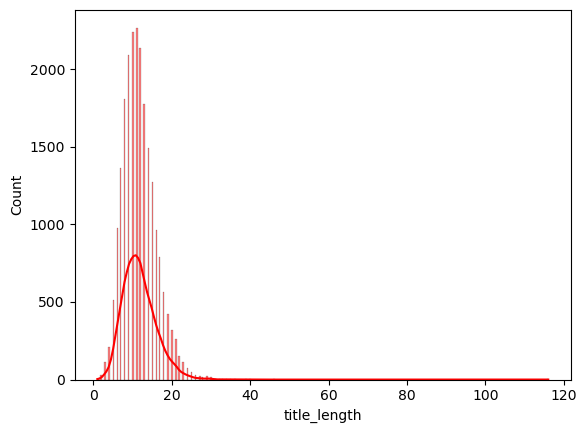

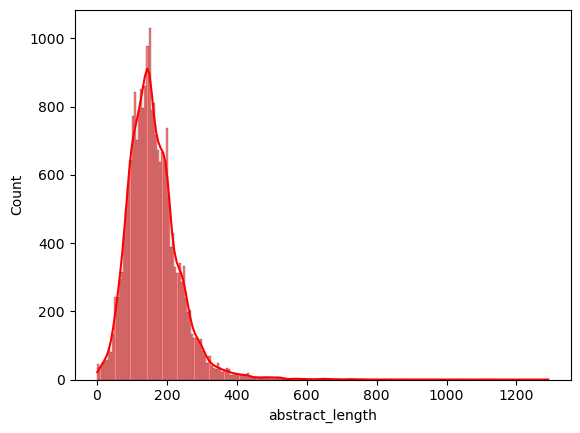

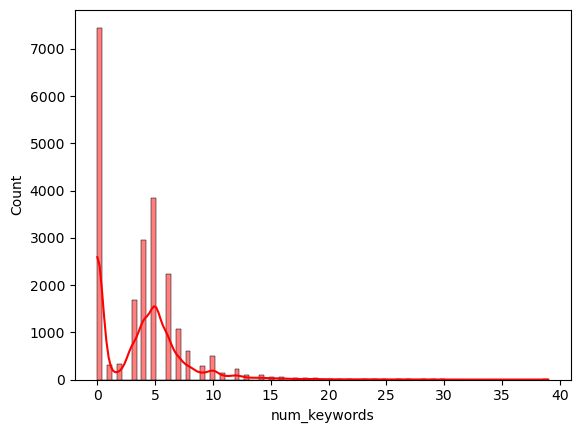

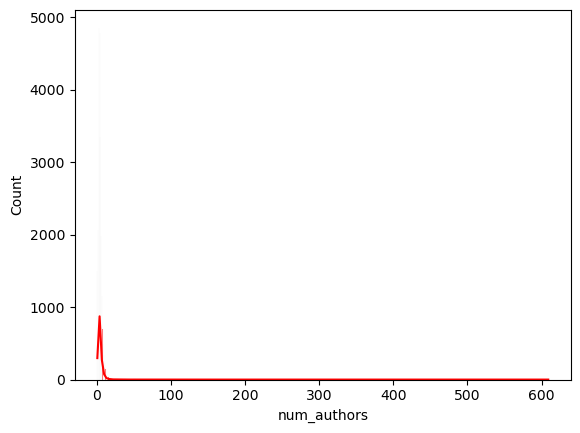

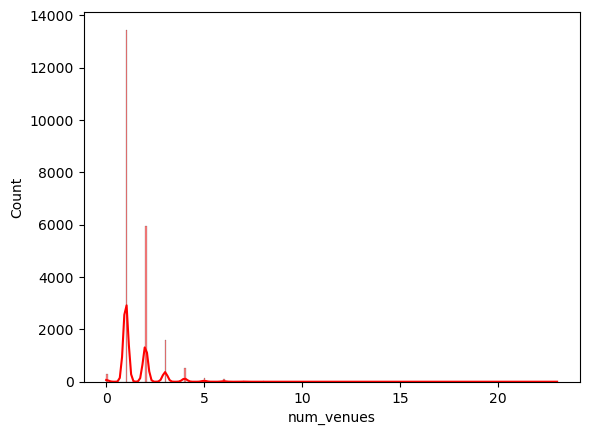

In [ ]:
for i in num_columns:
    sns.histplot(df_articles[i], kde=True, color="red")
    plt.show()


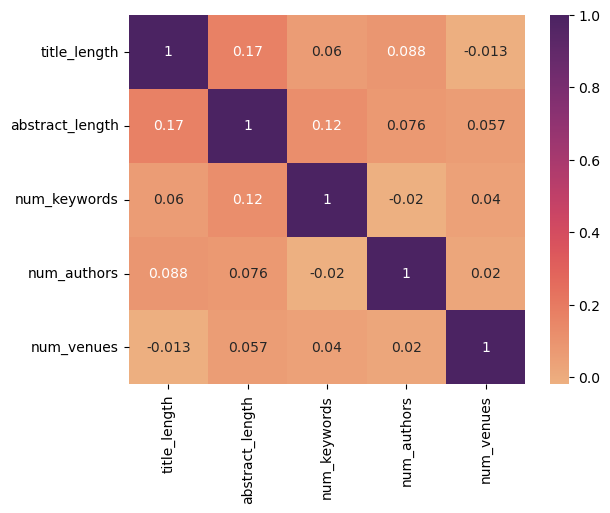

In [ ]:
corr_matrix = num_columns.corr()
sns.heatmap(corr_matrix, annot=True, cmap="flare")
plt.show()


<Axes: xlabel='count', ylabel='name'>

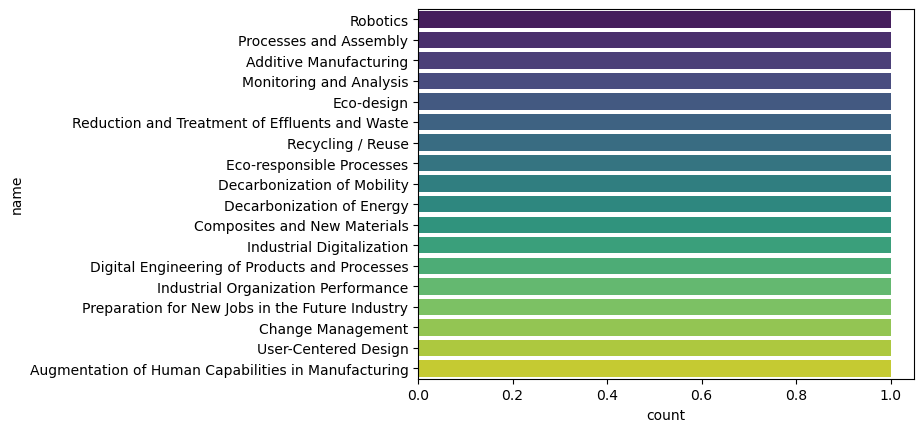

In [ ]:
sns.countplot(
    y="name",
    data=df_topics,
    order=df_topics["name"].value_counts().index,
    palette="viridis",
)


In [ ]:
df_articles["is_single_author"] = df_articles["num_authors"].apply(
    lambda x: 1 if x == 1 else 0
)


In [ ]:
X = num_columns
y = df_articles["is_single_author"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_preds = model.predict(X_test)
accuracy = accuracy_score(y_test, y_preds)
print(f"Prediction Accuracy: {accuracy}")


Prediction Accuracy: 1.0


<Axes: >

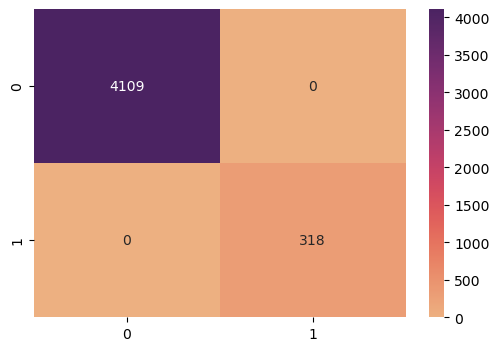

In [ ]:
cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="flare")
